In [3]:
import numpy as np
import pandas as pd
import yfinance as yf

google_df = yf.Ticker("GOOG").history(start="2010-01-01", end=None)

google_df


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-01-04 00:00:00-05:00,15.615220,15.678981,15.547723,15.610239,78541293,0.0,0.0
2010-01-05 00:00:00-05:00,15.620949,15.637387,15.480475,15.541497,120638494,0.0,0.0
2010-01-06 00:00:00-05:00,15.588072,15.588072,15.102393,15.149715,159744526,0.0,0.0
2010-01-07 00:00:00-05:00,15.178109,15.193053,14.760922,14.797037,257533695,0.0,0.0
2010-01-08 00:00:00-05:00,14.744733,15.024933,14.672753,14.994298,189680313,0.0,0.0
...,...,...,...,...,...,...,...
2023-08-17 00:00:00-04:00,130.449997,132.490997,129.850006,130.460007,23665600,0.0,0.0
2023-08-18 00:00:00-04:00,129.059998,129.830002,127.000000,128.110001,23619400,0.0,0.0
2023-08-21 00:00:00-04:00,127.849998,129.259995,127.160004,128.929993,21851100,0.0,0.0


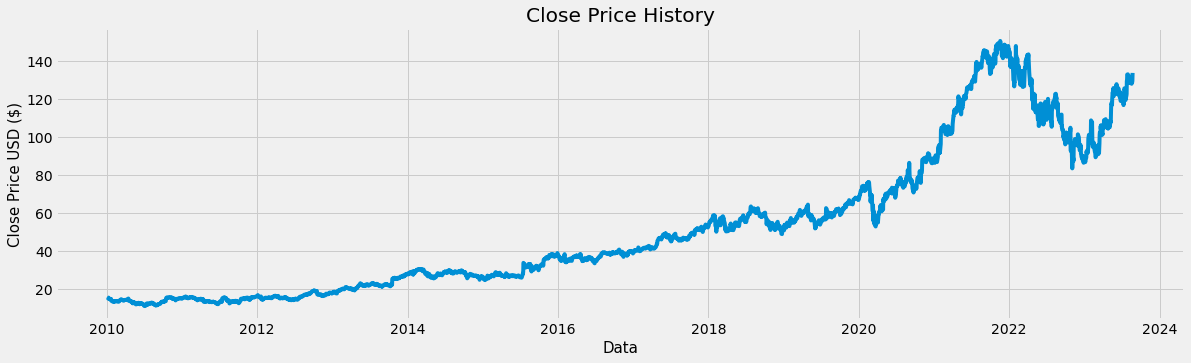

In [4]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

plt.figure(figsize=(18,5))
plt.title("Close Price History")
plt.plot(google_df['Close'])
plt.xlabel('Data', fontsize=15 )
plt.ylabel('Close Price USD ($)', fontsize=15)
plt.show()

In [18]:
import math
google_close = google_df.filter(['Close'])
dataset = google_close.values
n_training = math.ceil(len(dataset)*0.85)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
train_data = scaled_data[0:n_training]
x_train=[]
y_train = []
for i in range(180,len(train_data)):
    x_train.append(train_data[i-180:i,0])
    y_train.append(train_data[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))



(2739, 180, 1)

In [20]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [34]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=1, epochs=1)



2739/2739 [==============================] - 92s 33ms/step - loss: 2.7269e-04


In [27]:

test_data = scaled_data[n_training - 180: , : ]

x_test = []
y_test =  dataset[n_training : , : ] 
for i in range(180,len(test_data)):
    x_test.append(test_data[i-180:i,0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

In [29]:

predictions = model.predict(x_test) 
predictions = scaler.inverse_transform(predictions)

rmse=np.sqrt(np.mean(((predictions- y_test)**2)))


17/17 [==============================] - 0s 19ms/step


3.922038970085626

/tmp/ipykernel_291654/1403373762.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


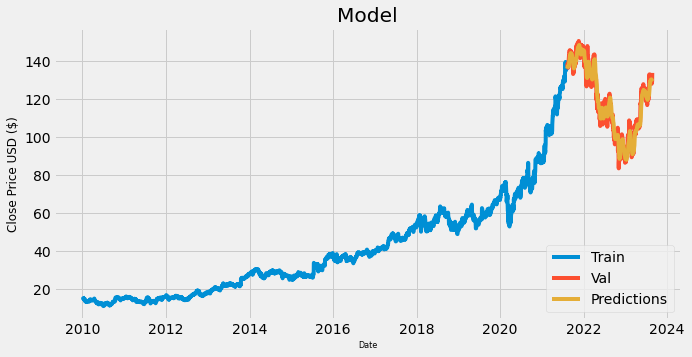

In [33]:
train = google_close[:n_training]
valid = google_close[n_training:]
valid['Predictions'] = predictions
#Visualize the data
plt.figure(figsize=(10,5))
plt.title('Model')
plt.xlabel('Date', fontsize=8)
plt.ylabel('Close Price USD ($)', fontsize=12)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [37]:
new_df = google_df.filter(['Close'])
 
last_180_days = new_df[-180:].values

last_180_days_scaled = scaler.transform(last_180_days)

X_test = []

X_test.append(last_180_days_scaled)

X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

pred_price = model.predict(X_test)
 
pred_price = scaler.inverse_transform(pred_price)
print("I morgen burde google-aksjen være", pred_price[0,0], "når børsen stenger")

1/1 [==============================] - 0s 19ms/step
I morgen burde google-aksjen være 138.55533 når børsen stenger
